In [1]:
import dgl
import torch
from dgl.data import CoraGraphDataset

print("Torch:", torch.__version__)
print("DGL:", dgl.__version__)
print("Environnement opérationnel !")

Torch: 2.4.0+cpu
DGL: 2.4.0
Environnement opérationnel !


/home/valentin/miniconda3/envs/pytorch-dgl-cpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Chargement du dataset Cora
dataset = CoraGraphDataset()
graph = dataset[0]  # le graphe unique du dataset

# Affichage de base
print("Type de graphe :", type(graph))
print("Résumé du graphe :", graph)

/home/valentin/.dgl/cora_v2.zip: 100%|██████████| 132k/132k [00:00<00:00, 480kB/s] 


Extracting file to /home/valentin/.dgl/cora_v2_d697a464
Finished data loading and preprocessing.
  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done saving data into cached files.
Type de graphe : <class 'dgl.heterograph.DGLGraph'>
Résumé du graphe : Graph(num_nodes=2708, num_edges=10556,
      ndata_schemes={'train_mask': Scheme(shape=(), dtype=torch.bool), 'val_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'label': Scheme(shape=(), dtype=torch.int64), 'feat': Scheme(shape=(1433,), dtype=torch.float32)}
      edata_schemes={})


## Structure du dataset Cora

Le dataset Cora est un graphe de citations scientifiques utilisé comme référence pour la classification de noeuds dans les graphes.

### 1. Représentation du graphe

- **noeuds** : chaque noeud représente un article scientifique.
- **Arêtes** : chaque arête représente une citation entre deux articles. Le graphe peut être considéré comme non orienté, car chaque citation est modélisée de façon symétrique.

### 2. Attributs disponibles dans `graph.ndata`

- `feat` : matrice de caractéristiques de taille `(N, 1433)` où `N` est le nombre de noeuds.  
  Chaque vecteur de taille 1433 est binaire (valeurs 0 ou 1) et encode la présence ou l’absence de mots-clés dans l’article correspondant.  
  Cette matrice est très creuse (sparse) : la grande majorité des composantes sont nulles.

- `label` : vecteur de labels entiers de taille `(N,)` indiquant la catégorie scientifique de chaque article.  
  Il existe 7 classes différentes (étiquetées de 0 à 6), correspondant à des domaines de recherche.

- `train_mask`, `val_mask`, `test_mask` : masques binaires (vecteurs de booléens de taille `(N,)`) indiquant l'appartenance de chaque noeud à l’un des sous-ensembles utilisés pour :
  - l'entraînement du modèle (`train_mask`)
  - la validation des performances pendant l'entraînement (`val_mask`)
  - le test final du modèle (`test_mask`)

### Exemple :

- `graph.ndata['feat'][i]` : vecteur de caractéristiques du noeud `i`.
- `graph.ndata['label'][i]` : classe associée au noeud `i`.
- `graph.ndata['train_mask'][i]` : vaut `True` si le noeud `i` est utilisé pour l'entraînement.

Ces informations permettent d'entraîner un modèle de classification de noeuds, en exploitant à la fois les caractéristiques individuelles des articles et la structure du graphe de citations.


In [15]:
#Exploration du graphe Cora

# Taille du graphe
print("Nombre de noeuds :", graph.num_nodes())
print("Nombre d’arêtes :", graph.num_edges())

#Vérification de la symétrie des arêtes
src, dst = graph.edges()

#Attributs disponibles pour les noeuds
print("Clés dans graph.ndata :", graph.ndata.keys())

#Dimensions des features (vecteurs de caractéristiques)
features = graph.ndata['feat']
print("Taille des features :", features.shape)  # (nb de noeuds, taille du vecteur)

# Affichage des labels de quelques noeuds
labels = graph.ndata['label']
print("Label du nœud 0 :", labels[0].item())

Nombre de noeuds : 2708
Nombre d’arêtes : 10556
Clés dans graph.ndata : dict_keys(['train_mask', 'val_mask', 'test_mask', 'label', 'feat'])
Taille des features : torch.Size([2708, 1433])
Label du nœud 0 : 3


### Questions de compréhension

1. On souhaite savoir si le graphe Cora est orienté ou non. En observant les arêtes, comment peut-on utilisez la fonction `has_edges_between(dst, src)` pour répondre à cette question.

2. Pourquoi peut-on traiter ce graphe comme un graphe non orienté, même si DGL le représente comme un graphe orienté en interne ? Quel est l'impact de cette décision sur le fonctionnement d’un GCN ?


In [4]:
# Définition d’un réseau GCN pour la classification de nœuds

import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import GraphConv

class GCN(nn.Module):
    def __init__(self, in_feats, hidden_size, num_classes):
        super().__init__()
        self.conv1 = GraphConv(in_feats, hidden_size)
        self.conv2 = GraphConv(hidden_size, num_classes)

    def forward(self, g, x):
        x = self.conv1(g, x)
        x = F.relu(x)
        x = self.conv2(g, x)
        return x

# Initialisation du modèle
in_feats = graph.ndata['feat'].shape[1]
num_classes = len(torch.unique(graph.ndata['label']))
model = GCN(in_feats=in_feats, hidden_size=64, num_classes=num_classes)

print(model)


GCN(
  (conv1): GraphConv(in=1433, out=64, normalization=both, activation=None)
  (conv2): GraphConv(in=64, out=7, normalization=both, activation=None)
)


In [ ]:
# Entraînement du modèle GCN (avec GPU si disponible)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device : {device}")

# Transfert des données sur le device
graph = graph.to(device)
features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].to(device)
train_mask = graph.ndata['train_mask'].to(device)
val_mask = graph.ndata['val_mask'].to(device)

# Transfert du modèle
model = model.to(device)

# Optimiseur
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

train_losses = []
val_accuracies = []

# Boucle d'entraînement
for epoch in range(1, 1001):
    model.train()
    logits = model(graph, features)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Évaluation sur validation
    model.eval()
    with torch.no_grad():
        val_logits = logits[val_mask]
        val_pred = val_logits.argmax(dim=1)
        val_acc = (val_pred == labels[val_mask]).float().mean()

    train_losses.append(loss.item())
    val_accuracies.append(val_acc.item())


    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Validation accuracy: {val_acc.item():.4f}")


Utilisation du device : cpu
Epoch 010 | Loss: 1.6618 | Validation accuracy: 0.6780
Epoch 020 | Loss: 1.0855 | Validation accuracy: 0.7680
Epoch 030 | Loss: 0.5159 | Validation accuracy: 0.7820
Epoch 040 | Loss: 0.2099 | Validation accuracy: 0.7820
Epoch 050 | Loss: 0.0908 | Validation accuracy: 0.7860
Epoch 060 | Loss: 0.0456 | Validation accuracy: 0.7900
Epoch 070 | Loss: 0.0271 | Validation accuracy: 0.7880
Epoch 080 | Loss: 0.0184 | Validation accuracy: 0.7880
Epoch 090 | Loss: 0.0138 | Validation accuracy: 0.7900
Epoch 100 | Loss: 0.0109 | Validation accuracy: 0.7900
Epoch 110 | Loss: 0.0090 | Validation accuracy: 0.7920
Epoch 120 | Loss: 0.0076 | Validation accuracy: 0.7900
Epoch 130 | Loss: 0.0066 | Validation accuracy: 0.7920
Epoch 140 | Loss: 0.0057 | Validation accuracy: 0.7920
Epoch 150 | Loss: 0.0050 | Validation accuracy: 0.7940
Epoch 160 | Loss: 0.0045 | Validation accuracy: 0.7940
Epoch 170 | Loss: 0.0040 | Validation accuracy: 0.7940
Epoch 180 | Loss: 0.0036 | Validation

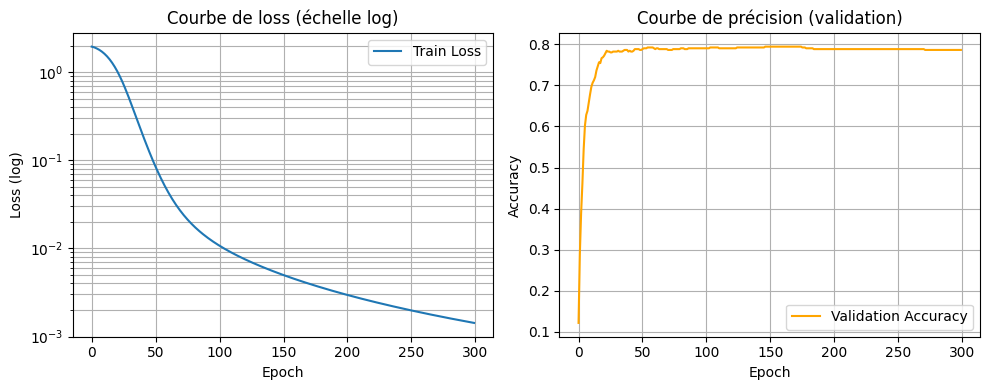

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Courbe de loss en échelle log
plt.subplot(1, 2, 1)
plt.semilogy(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Courbe de loss (échelle log)")
plt.grid(True, which="both")
plt.legend()

# Courbe de validation accuracy (échelle normale)
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label="Validation Accuracy", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Courbe de précision (validation)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# Évaluation finale du modèle sur le jeu de test (GPU-compatible)

test_mask = graph.ndata['test_mask'].to(device)

model.eval()
with torch.no_grad():
    logits = model(graph, features)  # logits est déjà sur le bon device
    test_logits = logits[test_mask]
    test_labels = labels[test_mask]  # labels est déjà sur le bon device
    test_pred = test_logits.argmax(dim=1)
    test_acc = (test_pred == test_labels).float().mean()

print(f"Test accuracy : {test_acc.item():.4f}")




Test accuracy : 0.7710


## Matrice de confusion

La matrice de confusion permet d’observer en détail la qualité des prédictions du modèle.  
Chaque ligne correspond à une **classe réelle**, chaque colonne à une **classe prédite**.

Une diagonale dominante indique que les prédictions sont majoritairement correctes.  
Les confusions fréquentes entre certaines classes peuvent refléter leur proximité thématique.


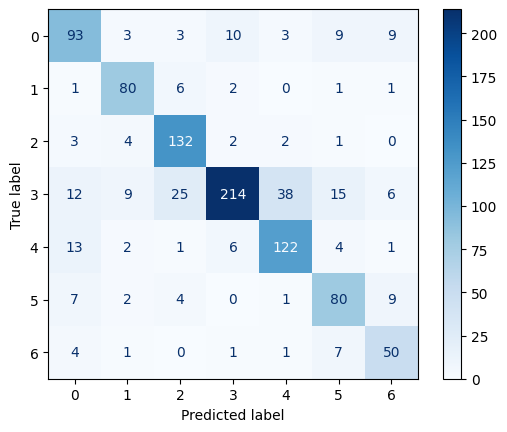

In [8]:
# Matrice de confusion sur le jeu de test

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    logits = model(graph, features)
    test_mask = graph.ndata['test_mask']
    y_true = labels[test_mask].cpu().numpy()
    y_pred = logits[test_mask].argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')


## Visualisation des embeddings (t-SNE)

Cette visualisation utilise la réduction de dimension t-SNE pour projeter les **représentations intermédiaires** des nœuds (après la première couche du GCN) dans un plan 2D.

Chaque point correspond à un nœud du graphe, coloré selon sa classe réelle.

Un bon regroupement des couleurs indique que le GCN a appris à séparer les différentes classes dans l’espace des représentations, ce qui facilite la classification finale.

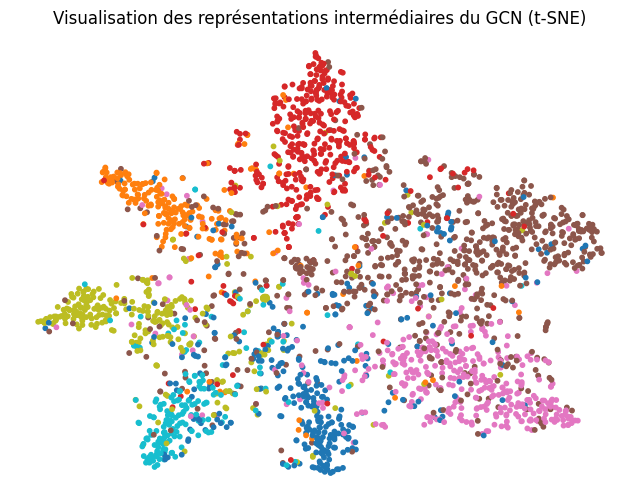

In [9]:
# Visualisation des embeddings appris par le GCN avec t-SNE

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extraction des représentations (sortie de la 1re couche)
with torch.no_grad():
    x = F.relu(model.conv1(graph, features)).cpu().numpy()
    y = labels.cpu().numpy()

# Réduction de dimension avec t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
x_2d = tsne.fit_transform(x)

# Affichage
plt.figure(figsize=(8, 6))
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y, cmap='tab10', s=10)
plt.title("Visualisation des représentations intermédiaires du GCN (t-SNE)")
plt.axis('off')
plt.show()



## Travail : Influence des hyperparamètres

Le modèle GCN défini dans ce TP comporte plusieurs **hyperparamètres** importants :

- `hidden_size` : dimension de la couche cachée (par défaut 16)
- `lr` : taux d'apprentissage de l'optimiseur (par défaut 0.005)
- `num_epochs` : nombre d'itérations d'entraînement (par défaut 1000)
- choix du nombre de **couches**, de la **fonction d'activation**, etc.

### Objectif

Modifiez un ou plusieurs de ces hyperparamètres pour observer leur effet sur :

- la **rapidité de convergence**
- la **précision sur le jeu de validation**
- le **score final sur le test**

Dans un premier temps, on vous propose de vous concentrer sur la taille cachée `hidden_size`.

### Travail demandé

1. Choisissez **un hyperparamètre à faire varier** (par exemple `hidden_size` ∈ {8, 32, 128, 512}).
2. Pour chaque valeur de cet hyperparamètre, réentraînez le modèle et :
   - stockez l’évolution de la **loss d’entraînement** à chaque epoch ;
   - stockez l’évolution de la **précision de validation** à chaque epoch.
3. Réalisez une **visualisation comparative** :
   - courbes d’**accuracy de validation** en fonction des epochs pour les différentes valeurs testées ;
   - éventuellement, courbes de **loss d’entraînement**.
4. À partir de ces courbes, choisissez une valeur “raisonnable” de l’hyperparamètre (par exemple une `hidden_size` qui offre un bon compromis entre performance et stabilité).
5. Avec cette configuration choisie :
   - évaluer **une seule fois** l’accuracy sur l’**ensemble de test** ;
   - comparer ce score de test à vos meilleurs scores de validation.

### Idée à discuter

- Pourquoi l’ensemble de **test** est-il gardé de côté pendant la phase d’exploration des hyperparamètres, et utilisé uniquement pour l’évaluation finale ?




## De GCN à GraphSAGE

In [ ]:
from dgl.nn import SAGEConv

# Détection du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# Définition du modèle GraphSAGE avec agrégation "mean"
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_size, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_feats, hidden_size, feat_drop=0, aggregator_type='mean')
        self.conv2 = SAGEConv(hidden_size, num_classes, feat_drop=0, aggregator_type='mean')

    def forward(self, g, x):
        x = self.conv1(g, x)
        x = F.relu(x)
        x = self.conv2(g, x)
        return x

# Transfert du graphe et des données sur le device
graph = graph.to(device)
features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].to(device)
train_mask = graph.ndata['train_mask'].to(device)
val_mask = graph.ndata['val_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

# Instanciation du modèle sur le bon device
model = GraphSAGE(in_feats=features.shape[1], hidden_size=32, num_classes=num_classes).to(device)

# Optimiseur
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_accuracies = []


# Entraînement
for epoch in range(1, 101):
    model.train()
    logits = model(graph, features)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = logits[val_mask]
        val_pred = val_logits.argmax(dim=1)
        val_acc = (val_pred == labels[val_mask]).float().mean()

    train_losses.append(loss.item())
    val_accuracies.append(val_acc.item())


    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Validation accuracy: {val_acc.item():.4f}")

# Évaluation finale
model.eval()
with torch.no_grad():
    logits = model(graph, features)
    test_logits = logits[test_mask]
    test_labels = labels[test_mask]
    test_pred = test_logits.argmax(dim=1)
    test_acc = (test_pred == test_labels).float().mean()

print(f"Test accuracy : {test_acc.item():.4f}")


Device utilisé : cpu
Epoch 010 | Loss: 0.8075 | Validation accuracy: 0.7380
Epoch 020 | Loss: 0.0786 | Validation accuracy: 0.7600
Epoch 030 | Loss: 0.0087 | Validation accuracy: 0.7560
Epoch 040 | Loss: 0.0025 | Validation accuracy: 0.7560
Epoch 050 | Loss: 0.0014 | Validation accuracy: 0.7560
Epoch 060 | Loss: 0.0010 | Validation accuracy: 0.7560
Epoch 070 | Loss: 0.0009 | Validation accuracy: 0.7560
Epoch 080 | Loss: 0.0008 | Validation accuracy: 0.7580
Epoch 090 | Loss: 0.0007 | Validation accuracy: 0.7560
Epoch 100 | Loss: 0.0007 | Validation accuracy: 0.7540
Test accuracy : 0.7680


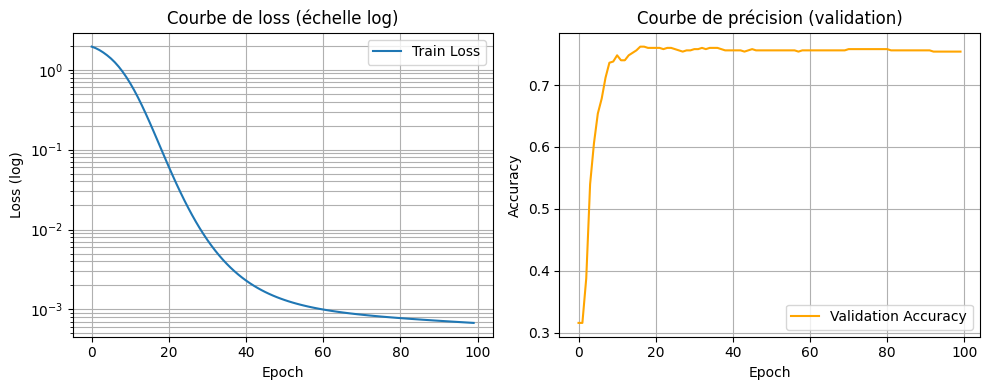

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Courbe de loss en échelle log
plt.subplot(1, 2, 1)
plt.semilogy(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Courbe de loss (échelle log)")
plt.grid(True, which="both")
plt.legend()

# Courbe de validation accuracy (échelle normale)
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label="Validation Accuracy", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Courbe de précision (validation)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Travail : Influence du type d’agrégateur dans GraphSAGE

On fixe désormais les hyperparamètres suivants pour tous les modèles GraphSAGE :

- `hidden_size = 32`
- `lr = 0.01`
- `num_epochs = 50`

On ne change **que** le type d’agrégateur dans `SAGEConv` parmi :
`aggregator_type ∈ { "mean", "gcn", "pool", "lstm" }`.

### 1. Mise en place des expériences

1. Entraînez un modèle GraphSAGE pour chacun des agrégateurs suivants :
   - `mean`
   - `gcn`
   - `pool`
   - `lstm`

   en gardant :
   - `hidden_size = 32`
   - `lr = 0.01`
   - `num_epochs = 50`.

2. Pour chaque agrégateur, enregistrez :
   - l’évolution de la **loss d’entraînement**,
   - l’évolution de l’**accuracy de validation**,
   - l’**accuracy finale sur le test** (évaluée une seule fois à la fin).

### 2. Analyse de la capacité de généralisation

3. Comparez les agrégateurs en termes de :
   - meilleure **accuracy de validation** atteinte,
   - **stabilité** des courbes,
   - **accuracy sur le test**.

   Lequel semble le mieux **généraliser** sur Cora avec ces hyperparamètres ?  
   Justifiez votre réponse à partir des scores de validation et de test.

### 3. Cas particulier de l’agrégateur LSTM

4. Comparez brièvement le comportement de `lstm` aux agrégateurs `mean` et `gcn` :
   - que remarquez-vous sur la **loss d’entraînement** et l’**accuracy de validation** ?
   - comment se situe son **score de test** ?

5. En une ou deux phrases, proposez des pistes pour améliorer la généralisation de `lstm`
   (par exemple en ajustant la taille cachée, le taux d’apprentissage ou en ajoutant
   de la régularisation comme du `dropout` ou du `weight_decay`).



## De GraphSAGE aux GAT

In [12]:
from dgl.nn import GATConv

class GAT(nn.Module):
    def __init__(self, in_feats, num_hidden, num_classes, num_heads=8, dropout=0.2):
        super().__init__()

        # Couche 1 : multi-head attention
        self.gat1 = GATConv(
            in_feats=in_feats,
            out_feats=num_hidden,
            num_heads=num_heads,
            feat_drop=dropout,
            attn_drop=dropout,
            activation=F.elu
        )

        # Couche 2 : une seule tête d'attention
        self.gat2 = GATConv(
            in_feats=num_hidden * num_heads,
            out_feats=num_classes,
            num_heads=1,
            feat_drop=dropout,
            attn_drop=dropout,
            activation=None  # Pas de softmax ici
        )

    def forward(self, g, x):
        x = self.gat1(g, x)
        x = x.flatten(1)  # concatène les têtes
        x = self.gat2(g, x)
        return x.squeeze(1)  # supprime la tête unique


#Transfert des données sur le GPU (si disponible)
graph = graph.to(device)
features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].to(device)
train_mask = graph.ndata['train_mask'].to(device)
val_mask = graph.ndata['val_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

#Instanciation du modèle
model = GAT(in_feats=features.shape[1], num_hidden=8, num_classes=num_classes, num_heads=8).to(device)

#Optimiseur
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

train_losses = []
val_accuracies = []

for epoch in range(1, 301):
    model.train()
    logits = model(graph, features)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = logits[val_mask]
        val_pred = val_logits.argmax(dim=1)
        val_acc = (val_pred == labels[val_mask]).float().mean()

    train_losses.append(loss.item())
    val_accuracies.append(val_acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Validation accuracy: {val_acc.item():.4f}")

# Évaluation finale
model.eval()
with torch.no_grad():
    logits = model(graph, features)
    test_logits = logits[test_mask]
    test_labels = labels[test_mask]
    test_pred = test_logits.argmax(dim=1)
    test_acc = (test_pred == test_labels).float().mean()

print(f"Test accuracy : {test_acc.item():.4f}")

Epoch 010 | Loss: 1.7714 | Validation accuracy: 0.7120
Epoch 020 | Loss: 1.5393 | Validation accuracy: 0.7460
Epoch 030 | Loss: 1.3475 | Validation accuracy: 0.7340
Epoch 040 | Loss: 1.0407 | Validation accuracy: 0.7360
Epoch 050 | Loss: 0.8743 | Validation accuracy: 0.7360
Epoch 060 | Loss: 0.6593 | Validation accuracy: 0.7140
Epoch 070 | Loss: 0.5706 | Validation accuracy: 0.7080
Epoch 080 | Loss: 0.5442 | Validation accuracy: 0.7320
Epoch 090 | Loss: 0.4658 | Validation accuracy: 0.7280
Epoch 100 | Loss: 0.3689 | Validation accuracy: 0.7120
Epoch 110 | Loss: 0.4395 | Validation accuracy: 0.7320
Epoch 120 | Loss: 0.3866 | Validation accuracy: 0.7040
Epoch 130 | Loss: 0.3639 | Validation accuracy: 0.7400
Epoch 140 | Loss: 0.3936 | Validation accuracy: 0.7020
Epoch 150 | Loss: 0.3664 | Validation accuracy: 0.7260
Epoch 160 | Loss: 0.3096 | Validation accuracy: 0.7020
Epoch 170 | Loss: 0.3487 | Validation accuracy: 0.7180
Epoch 180 | Loss: 0.3627 | Validation accuracy: 0.7140
Epoch 190 

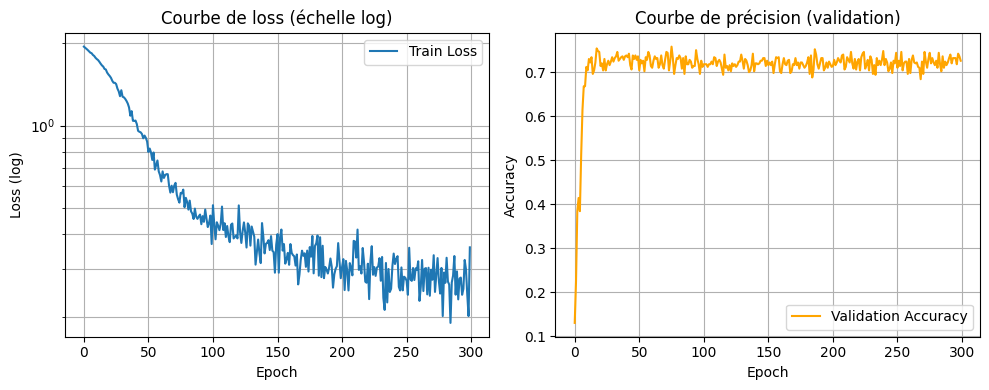

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Courbe de loss en échelle log
plt.subplot(1, 2, 1)
plt.semilogy(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Courbe de loss (échelle log)")
plt.grid(True, which="both")
plt.legend()

# Courbe de validation accuracy (échelle normale)
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label="Validation Accuracy", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Courbe de précision (validation)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



### Questions sur le fonctionnement de GAT

1. **Objectif de l’attention**

   Quel est l’objectif du mécanisme d’attention dans un GAT ?  
   En quoi cette approche diffère-t-elle de l’agrégation de voisinage utilisée dans GCN ou GraphSAGE (où les voisins sont moyennés ou sommés avec des poids fixes) ?

2. **Multi-head attention**

   Pourquoi utilise-t-on plusieurs "têtes" (`num_heads`) dans la première couche GAT ?  
   Quel est l’effet attendu de la concaténation des sorties multi-têtes sur la représentation finale des nœuds ?

3. **Influence du nombre de têtes d’attention à capacité fixe**

On souhaite étudier l’effet du nombre de têtes d’attention `num_heads` sans changer
la capacité totale du modèle.

1. Modifiez le modèle GAT pour fixer une **dimension cachée totale** `total_hidden_dim`
   (par exemple `128`), et ajuster automatiquement la dimension **par tête** :
   $$
   \text{hidden\_per\_head} = \frac{\text{total\_hidden\_dim}}{\text{num\_heads}}
   $$
   de sorte que, après concaténation des têtes, on obtienne toujours une représentation
   de taille `total_hidden_dim`, quel que soit `num_heads`.

2. En utilisant ce modèle à capacité fixe, faites varier `num_heads` (par exemple
   `num_heads ∈ {1, 2, 4, 8, 16}`) en gardant tous les autres hyperparamètres identiques
   (`total_hidden_dim`, `lr`, `weight_decay`, `num_epochs`, etc.).

   Pour chaque valeur de `num_heads` :
   - enregistrez l’évolution de l’**accuracy de validation**,
   - mesurez l’**accuracy sur le test** (une seule fois à la fin).

3. Analysez les résultats obtenus :
   - comment évoluent les **meilleurs scores de validation** et de **test** lorsque `num_heads` augmente,
     à capacité totale fixe ?
   - observe-t-on un intérêt à utiliser plusieurs têtes plutôt qu’une seule,
     même quand la dimension totale du modèle reste la même ?
   - jusqu’à quel point l’augmentation du nombre de têtes semble bénéfique sur ce problème ?


### Propose ton meilleur modèle selon tes critères.

## Partie bonus – Changer d’échelle : le dataset **PubMed**

Dans cette section, nous vous proposons de réutiliser tout ce que vous avez vu sur Cora (GCN, GraphSAGE, GAT, réglage des hyperparamètres…) sur un **autre graphe de citations** : le dataset **PubMed**.

### Description du jeu de données PubMed

Le jeu de données PubMed (version citation network) est, comme Cora, un **graphe de citations d’articles scientifiques**, mais de plus grande taille.

- **Nœuds** : articles scientifiques publiés dans la base *PubMed*.
- **Arêtes** : relations de **citation** entre articles (souvent symétrisées dans les implémentations).
- **Tâche** : classification de nœuds (prédire le **thème principal** de l’article).
- **Caractéristiques des nœuds** :
  - vecteurs de caractéristiques réelles (par exemple basés sur des pondérations TF-IDF de mots),
  - dimension des features typiquement **plus faible que Cora**, mais les valeurs sont **continues** (et non binaires).
- **Labels** :
  - chaque nœud est associé à une des **3 classes** (thématiques médicales différentes).

Par rapport à Cora :

- le graphe est **plus grand** (plus de nœuds, plus d’arêtes),
- les features sont **continues** et non binaires,
- le problème reste une **classification supervisée de nœuds** avec séparation train / validation / test.

L’objectif est de voir si vos modèles et vos intuitions se **généralisent** lorsque l’on change de jeu de données et d’échelle.

---

### Consignes

1. **Charger** le dataset PubMed et récupérer :
   - le graphe `pubmed_graph`,
   - les tenseurs `features`, `labels`,
   - les masques `train_mask`, `val_mask`, `test_mask`.

2. **Explorer** le graphe :
   - nombre de nœuds et d’arêtes,
   - dimension des features,
   - nombre de classes et distribution des labels,
   - vérifier si le graphe est symétrique ou non.

3. **Réutiliser** (si vous le souhaitez) :
   - votre meilleur modèle entraîné sur Cora (GCN, GraphSAGE, GAT ou autre),
   - ou proposer une nouvelle architecture adaptée à PubMed.

4. **Comparer** qualitativement :
   - le comportement de l’apprentissage (courbes de loss / accuracy),
   - la difficulté apparente du problème,
   - l’influence de la taille du graphe et des hyperparamètres.

> Le but est ici exploratoire : vous avez à disposition tous les outils vus sur Cora, à vous de choisir comment les adapter à PubMed.

---

### Code de départ : import et accès aux données

Vous pouvez utiliser le code suivant comme point de départ dans une cellule *code*.

```python
import torch
from dgl.data import PubmedGraphDataset

# 1) Chargement du dataset PubMed
pubmed_dataset = PubmedGraphDataset()
pubmed_graph = pubmed_dataset[0]

print(pubmed_dataset)
print(pubmed_graph)
